In [1]:
# This script creates initial figures for the paper for Neches simulations

In [2]:
# Import packages
import sys, os
import h5py
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.dates as mdates
from matplotlib import pyplot as plt
from matplotlib import cm as pcm
import copy
%matplotlib inline
# import ipympl
# %matplotlib ipympl
# import hydrofunctions as hf
from datetime import datetime, timedelta
import time
import calendar
import watershed_workflow 
from shapely.geometry import Polygon
# import hydroeval as he
# from sklearn.metrics import r2_score
from matplotlib import gridspec
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import contextily as ctx
from shapely.geometry import Point
from shapely.affinity import scale
from shapely.geometry import box
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import watershed_workflow 
import watershed_workflow.source_list
import watershed_workflow.ui
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.densification
import watershed_workflow.condition
import watershed_workflow.land_cover_properties
import rasterio
import pickle


In [3]:
# path to save figures
path_figures = '/Users/gpq/ORNL/Projects/ATS_runs/setx_campaigns/setx-neches/scripts/Figures_paper'

# Figure 1:

Location of case study showing the (a) regional and global location, (b) Manning coefficient, (c) Surface elevation and river network, (d) Land Cover type, (e) Soil Type, and (f) Geology type. The inset in panel (a) shows the location of the case study in the United States.


In [4]:
# Load data

crs = watershed_workflow.crs.daymet_crs()
name = 'neches'
outputs = {}
outputs['m2_temp'] = f'../../../../global_data/meshes/{name}_m2_temp.pkl'
outputs['rivers_temp'] = f'../../../../global_data/meshes/{name}_rivers_temp.pkl'
outputs['watershed_temp'] = f'../../../../global_data/meshes/{name}_watershed_temp.pkl'
outputs['subdomains_temp'] = f'../../../../global_data/meshes/{name}_subdomains_temp.pkl'


m2 = pickle.load(open(outputs['m2_temp'], 'rb'))
rivers = pickle.load(open(outputs['rivers_temp'], 'rb'))
watershed = pickle.load(open(outputs['watershed_temp'], 'rb'))
subdomains = pickle.load(open(outputs['subdomains_temp'], 'rb'))


In [66]:
outputs['lc'] = f'../../../../global_data/meshes/{name}_lc.pkl'
lc = pickle.load(open(outputs['lc'], 'rb'))

outputs['manning'] = f'../../../../global_data/meshes/{name}_manning.pkl'
manning = pickle.load(open(outputs['manning'], 'rb'))

outputs['soil_colors'] = f'../../../../global_data/meshes/{name}_soil_color.pkl'
soil_color = pickle.load(open(outputs['soil_colors'], 'rb'))

outputs['soil_survey_props'] = f'../../../../global_data/meshes/{name}_soil_survey_props.pkl'
soil_survey_props = pickle.load(open(outputs['soil_survey_props'], 'rb'))

outputs['geo_colors'] = f'../../../../global_data/meshes/{name}_geo_color.pkl'
geo_color = pickle.load(open(outputs['geo_colors'], 'rb'))

outputs['geo_survey_props'] = f'../../../../global_data/meshes/{name}_geo_survey_props.pkl'
geo_survey_props = pickle.load(open(outputs['geo_survey_props'], 'rb'))

outputs['DTB'] = f'../../../../global_data/meshes/{name}_DTB.pkl'
DTB = pickle.load(open(outputs['DTB'], 'rb'))

In [5]:
# Load gages with info
gdf_gages = gpd.read_file('../../data-processed/neches_gages.shp')

# Remove the following gages
excluded_gages = ['Pine Island Bayou abv BI Pump Plant, Beaumont, TX', 'Bayou Lanana at Nacogdoches, TX','Neches Rv at Evadale, TX']
gdf_gages = gdf_gages[~gdf_gages['STANAME'].isin(excluded_gages)]

In [6]:

outlet_table = pd.DataFrame(watershed.properties)

# Create a column as x and y
outlet_table['x'] = 0
outlet_table['y'] = 0

for i in np.arange(0,len(outlet_table)):
    outlet_table['x'][i] = outlet_table['outlet_point'][i][0]
    outlet_table['y'][i] = outlet_table['outlet_point'][i][1]

# Sort the table from the smallest to the largest y
outlet_table = outlet_table.sort_values(by='y')
# Reset index
outlet_table = outlet_table.reset_index(drop=True)

# Create a column as Label plot, from 1 to n
outlet_table['Label'] = np.arange(1, len(outlet_table)+1)

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_74385/3696786906.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlet_table['x'][i] = outlet_table['outlet_point'][i][0]
/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_74385/3696786906.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlet_table['y'][i] = outlet_table['outlet_point'][i][1]


In [7]:
#  join outlet_table with gdf_gages, using the STANAME in gdf_gages and name in outlet_table, and keep all the rows in outlet_table
outlet_table = outlet_table.merge(gdf_gages, left_on='name', right_on='STANAME', how='left')

# Fill drainage area for GV Bay outlet and Neches River
outlet_table.loc[outlet_table['name'] == 'GV Bay outlet', 'DRAIN_SQKM'] = rivers[1].properties['ContributingAreaSqKm']
outlet_table.loc[outlet_table['name'] == 'Neches River', 'DRAIN_SQKM'] = rivers[0].properties['ContributingAreaSqKm']


In [8]:
# round to integers
outlet_table['DRAIN_SQKM'] = outlet_table['DRAIN_SQKM'].astype(int)


/Users/gpq/anaconda3/envs/Backup_watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


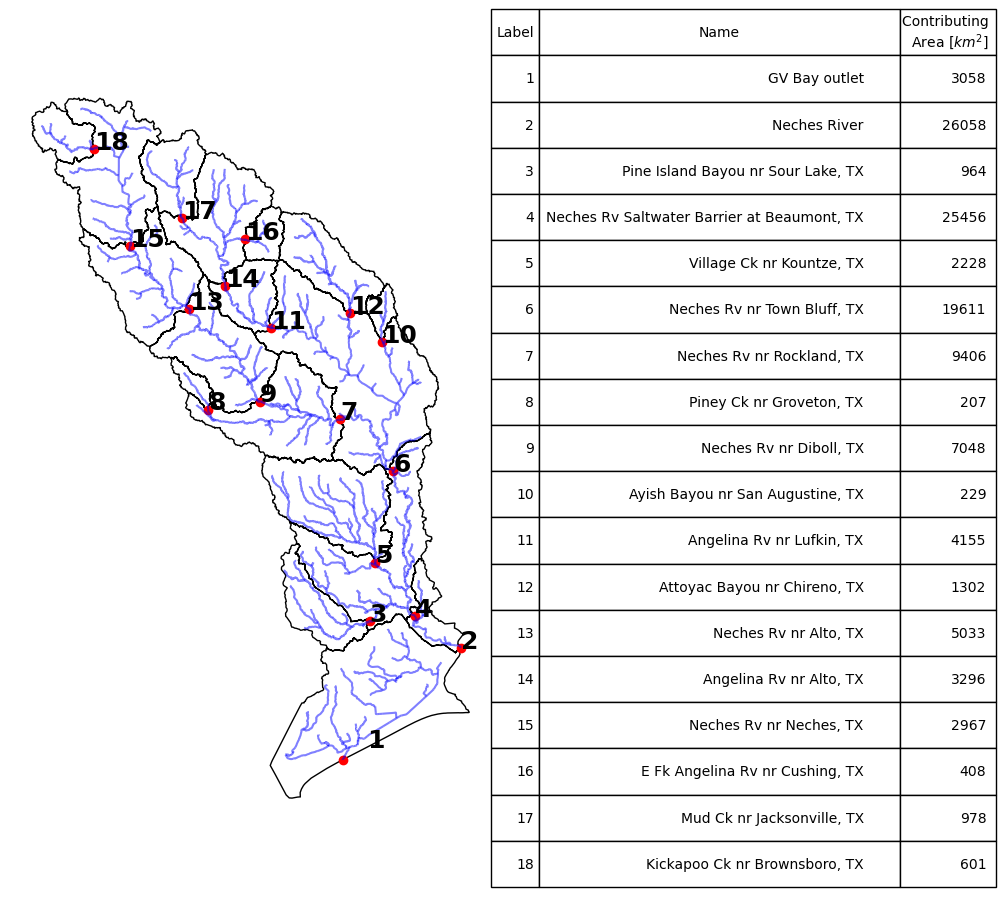

In [88]:
%matplotlib inline
# Make initial plot
fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10, 10), ncol=1, nrow=1)

# create a subplot with 1 row and 2 column
# fig, ax = plt.subplots(1, 2, figsize=(10, 10), subplot_kw={'projection': crs})

watershed_workflow.plot.hucs(watershed , crs, 'k', ax)
watershed_workflow.plot.rivers(rivers, crs,'b', ax, alpha = 0.5)
watershed_workflow.plot.shplys(watershed.polygon_outlets , crs, 'r', ax, marker = 'o', markersize = 30)
# ax.plot(outlet_table['x'],outlet_table['y'], 'ro')

# Show label for each point,  using outlet_table['Label']
for i, txt in enumerate(outlet_table['Label']):
    ax.annotate(txt, (outlet_table['x'][i],outlet_table['y'][i]), color='black', fontsize=18, fontweight='bold')
# remove the axis
ax.axis('off')

# Create a table with the label of each outlet and the name of the watershed, and fix column width and height
# ax.table(cellText=outlet_table[['Label', 'watershed_name']].values, colLabels=['Label', 'Watershed'], loc='bottom', cellLoc='center', colLoc='center', cellColours=[['lightgray']*2]*len(outlet_table), cellColWidth=[0.1, 0.3])

table = plt.table(cellText=outlet_table[['Label', 'name', 'DRAIN_SQKM']].values,
          colLabels=['Label', 'Name', 'Contributing \n Area [$km^2$]'],
          loc='right',  # Changed 'right' to 'center right'
          colWidths=[0.1, 0.75, 0.2])  # Changed 'cellColWidth' to 'colWidths'

# Set the height of each row
row_height = 0.06  # Example row height, you can adjust this value
for pos, cell in table.get_celld().items():
    cell.set_height(row_height)

# Set the font size of the table
table.auto_set_font_size(False)

# Adjust layout as needed to make sure the table is visible
# plt.tight_layout()

# Show the plot
plt.show()

fig.savefig(path_figures+'/Figure_gages_basins.png', dpi=300, bbox_inches='tight')

kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x33bf69420>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x33bf6a4a0>, 'edgecolor': 'w'}
setting face color =  [110.51894569 121.24179343  96.4969464  ...  -1.61300004  -1.61300004
  -1.61300004]


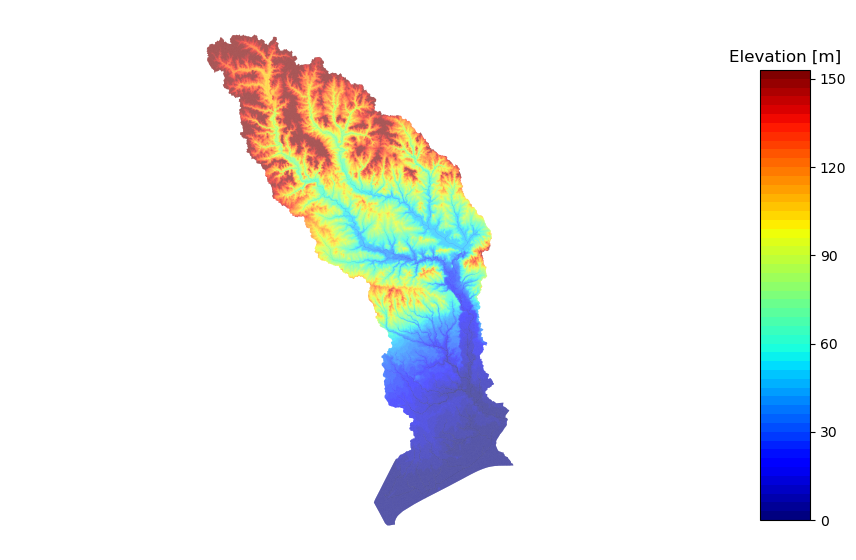

In [74]:

# plot the resulting surface mesh
start=min(m2.centroids[:,2])
step=(max(m2.centroids[:,2])-(min(m2.centroids[:,2])))/40
stop=max(m2.centroids[:,2])+step
# legend_values=np.arange(start,stop,step)
legend_values=np.arange(0,153,3)
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(legend_values, cmap='jet')


fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cbax = fig.add_axes([0.75,0.05,0.05,0.75])


mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, 
                        linewidth=0 ,color=m2.centroids[:,2], 
                        cmap=cmap, norm = norm, edgecolor='w', facecolor='color', vmin=0, vmax=150)
# # remove the axis
ax.axis('off')

cbar = fig.colorbar(mp, orientation="vertical", cax=cbax)
# set color bar in vertical
# cbar = fig.colorbar(mp, orientation="horizontal", cax=cbax)
# cbar = fig.colorbar(mp, orientation="horizontal", ax=ax)
# set the cbar from 5 to 150 with step of 30
ticks = [0, 30, 60, 90, 120, 150]
labels = [0, 30, 60, 90, 120, 150]
cbar.set_ticks(ticks)
cbar.set_ticklabels(labels)


# watershed_workflow.plot.rivers(rivers, crs, ax=ax, colors='b', linewidth=0.5)
# watershed_workflow.plot.hucs(watershed, crs, ax=ax, linewidth=1, facecolor='color', alpha=0.4)
# ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')
cbar.ax.set_title('Elevation [m]')
# cbar.orientation = 'horizontal'

# ax.text(0.1, 0.98, '(c)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')


plt.show()
fig.savefig(path_figures+'/Figure_DEM.png', dpi=300, bbox_inches='tight')


/Users/gpq/anaconda3/envs/Backup_watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x33bf7fe20>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x33bf7fdf0>}
setting face color =  [42 42 43 ... 22 22 22]


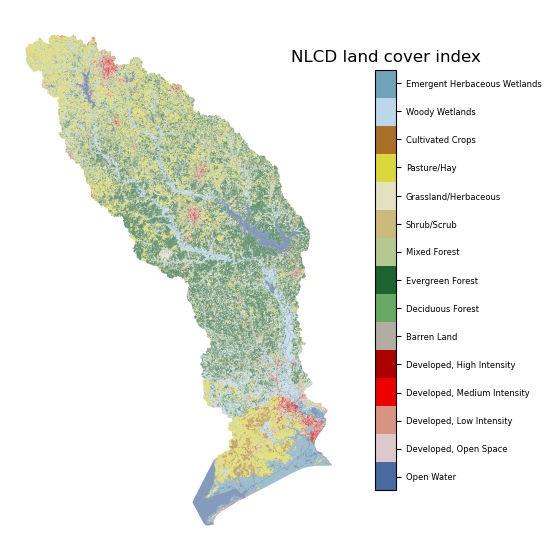

In [73]:
nlcd_indices, nlcd_cmap, nlcd_norm, ticks, nlcd_labels = \
        watershed_workflow.colors.generate_nlcd_colormap(lc)

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
# cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=lc, 
                        cmap=nlcd_cmap, norm=nlcd_norm
                       )

# cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(lc)), 
#                                                 cmap=nlcd_cmap, labels=nlcd_labels, cax=cax)

cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(lc)), 
                                                cmap=nlcd_cmap, labels=nlcd_labels)
cbar.ax.tick_params(labelsize=6)
cbar.orientation = 'horizontal'

# # Find the pos of the values of lc equal to zero
# pos = np.where(lc == 0)
# # plot the centroid of those elements
# ax.scatter(m2.centroids[pos,0], m2.centroids[pos,1], c='k', marker='o', s=1)

# cbar = fig.colorbar(mp, cax=cax)
cbar.ax.set_title('NLCD land cover index')

# ax.set_title('NLCD land cover index')
ax.axis('off')
plt.show()
fig.savefig(path_figures+'/Figure_Land_Cover.png', dpi=300, bbox_inches='tight')

kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x33b7a9330>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x33c1fa950>}
setting face color =  [0.08 0.08 0.08 ... 0.2  0.2  0.2 ]


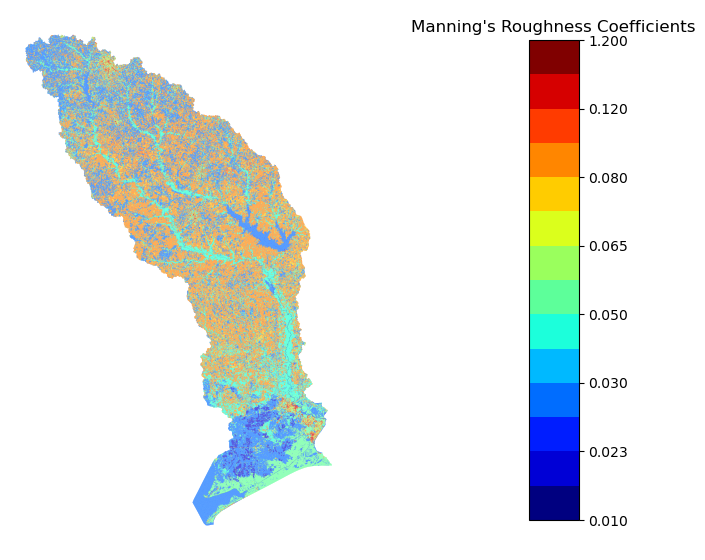

In [25]:
# Manning 
legend_values=np.arange(0,153,3)
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(legend_values, cmap='jet')


indices, cmap, norm, ticks, labels = \
        watershed_workflow.colors.generate_indexed_colormap(manning, cmap='jet') # 'tab20c'
fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=manning, 
                        cmap=cmap, norm=norm
                       )

# cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(manning)), 
#                                                 cmap=cmap, labels=labels, cax=cax)
# cbar.ax.tick_params(labelsize=6)

cbar = fig.colorbar(mp, cax=cax)
cbar.ax.set_title('Manning\'s Roughness Coefficients')

# ax.set_title('Manning\'s Roughness Coefficients')
ax.axis('off')
plt.show()

fig.savefig(path_figures+'/Figure_Manning.png', dpi=300, bbox_inches='tight')

kwargs =  {'linewidth': 0.5, 'cmap': <matplotlib.colors.ListedColormap object at 0x33ba03160>}
setting face color =  [0.39325688 0.35684729 0.41407895 ... 0.         0.         0.        ]


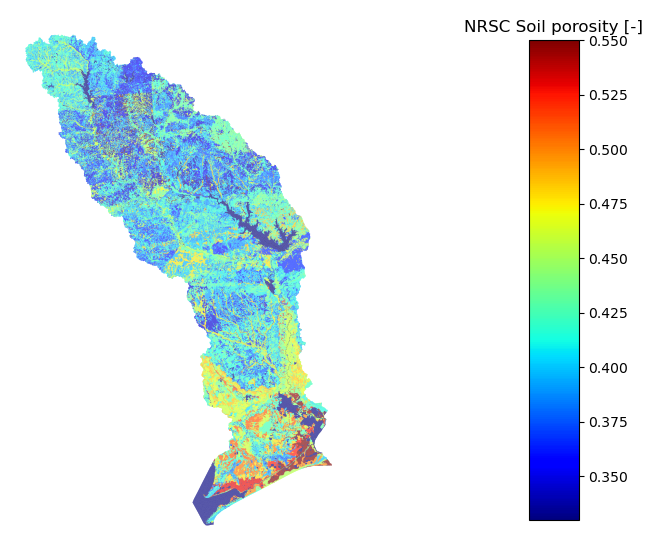

In [29]:
# Soil pososity from NRSC
# plot the soil porosity 
# plot of porosity from SSURGO
iprop = np.empty(soil_color.shape, 'd')
for mukey in soil_survey_props['native_index']:
    # iprop[soil_color == mukey] = soil_survey_props.loc[ mukey,'porosity [-]']
    iprop[soil_color == mukey] = soil_survey_props[soil_survey_props['native_index']==mukey]['porosity [-]'].values[0]

pmin_plot = 0.33
pmax_plot = 0.55

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.5, color=iprop, cmap=cmap, facecolor='color', vmin=pmin_plot, vmax=pmax_plot)


# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=iprop, edgecolor='gray', cmap='jet')
# ax.set_title('soil porosity [-]')
# cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend="both", shrink=0.6)

cbar = fig.colorbar(mp, cax=cax)
cbar.ax.set_title('NRSC Soil porosity [-]')

ax.axis('off')



# print('Median porosity [-] = ', np.nanmedian(iprop))
plt.show()
fig.savefig(path_figures+'/Figure_soil porosity.png', dpi=300, bbox_inches='tight')

/Users/gpq/anaconda3/envs/Backup_watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0.5, 'cmap': <matplotlib.colors.ListedColormap object at 0x33c279e70>}
setting face color =  [0.22 0.27 0.19 ... 0.05 0.05 0.05]


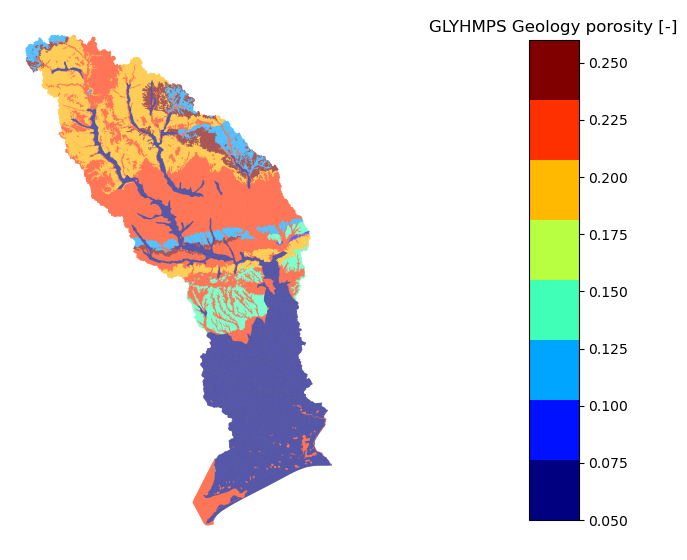

In [67]:
# Geology porosity GLYMPS
geo_color = geo_color.astype(int)
iprop = np.empty(geo_color.shape, 'd')
for i in geo_survey_props.index:
    # iprop[geo_color == i] = geo_survey_props.loc[i, 'porosity [-]']
    iprop[geo_color == i] = geo_survey_props[geo_survey_props['id']==i]['porosity [-]'].values[0]

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.5, color=iprop, cmap=cmap, facecolor='color', vmin=0.05, vmax=0.26)

cbar = fig.colorbar(mp, cax=cax)
cbar.ax.set_title('GLYHMPS Geology porosity [-]')

ax.axis('off')
plt.show()

fig.savefig(path_figures+'/Figure_geo_porosity.png', dpi=300, bbox_inches='tight')

kwargs =  {'linewidth': 0.1, 'cmap': <matplotlib.colors.ListedColormap object at 0x33bb58550>}
setting face color =  [ 1.          1.35763608  1.53417864 ... 50.         50.
 50.        ]


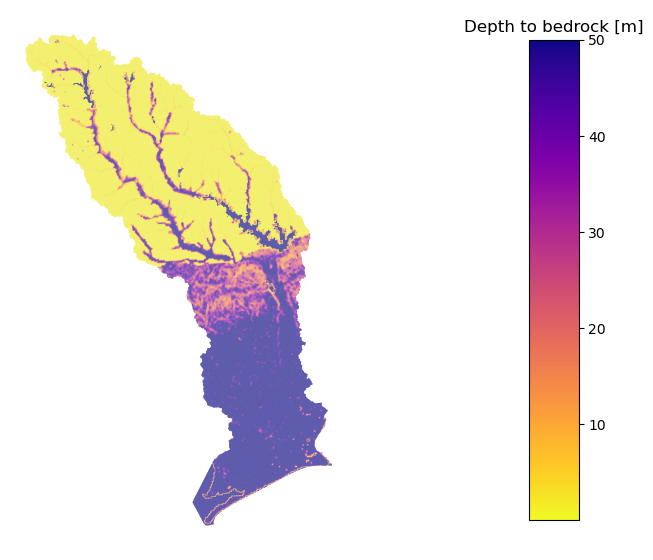

In [68]:
# Depth to bed rock

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(DTB, cmap='plasma_r')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.1, color=DTB, cmap=cmap, facecolor='color')

# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=DTB, cmap='plasma_r', edgecolor='white', linewidth=0.1)

cbar = fig.colorbar(mp, cax=cax)
cbar.ax.set_title('Depth to bedrock [m]')

ax.axis('off')
plt.show()

fig.savefig(path_figures+'/Figure_DTB.png', dpi=300, bbox_inches='tight')